Dataset Shape: (278205, 58)
✔ Data types fixed


/tmp/ipython-input-3675832920.py:47: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipython-input-3675832920.py:52: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

✔ Missing values handled

🔍 Outlier Summary (IQR method):
innings: 0 potential outliers
over: 0 potential outliers
ball: 0 potential outliers
ball_no: 0 potential outliers
bat_pos: 0 potential outliers
balls_faced: 0 potential outliers
runs_batter: 0 potential outliers
runs_extras: 0 potential outliers
runs_total: 0 potential outliers
runs_bowler: 0 potential outliers
runs_not_boundary: 0 potential outliers
team_runs: 0 potential outliers
team_balls: 0 potential outliers
team_wicket: 0 potential outliers
balls_per_over: 0 potential outliers
overs: 0 potential outliers
batter_runs: 0 potential outliers
batter_balls: 0 potential outliers
bowler_wicket: 0 potential outliers


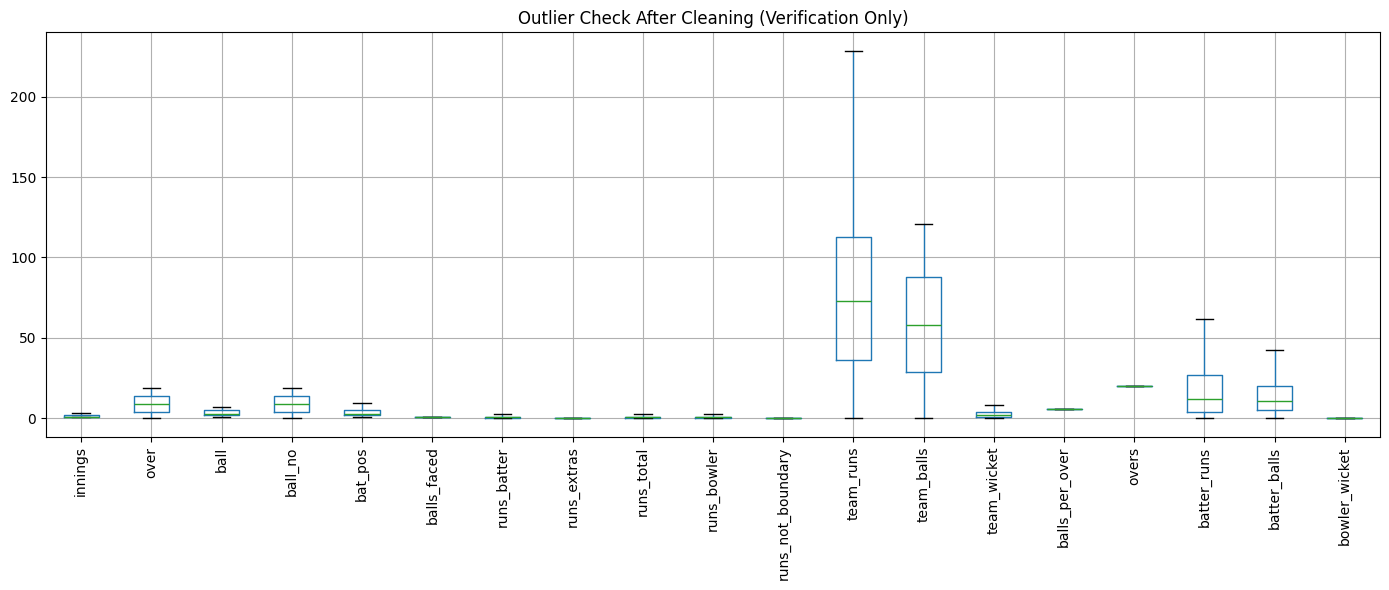

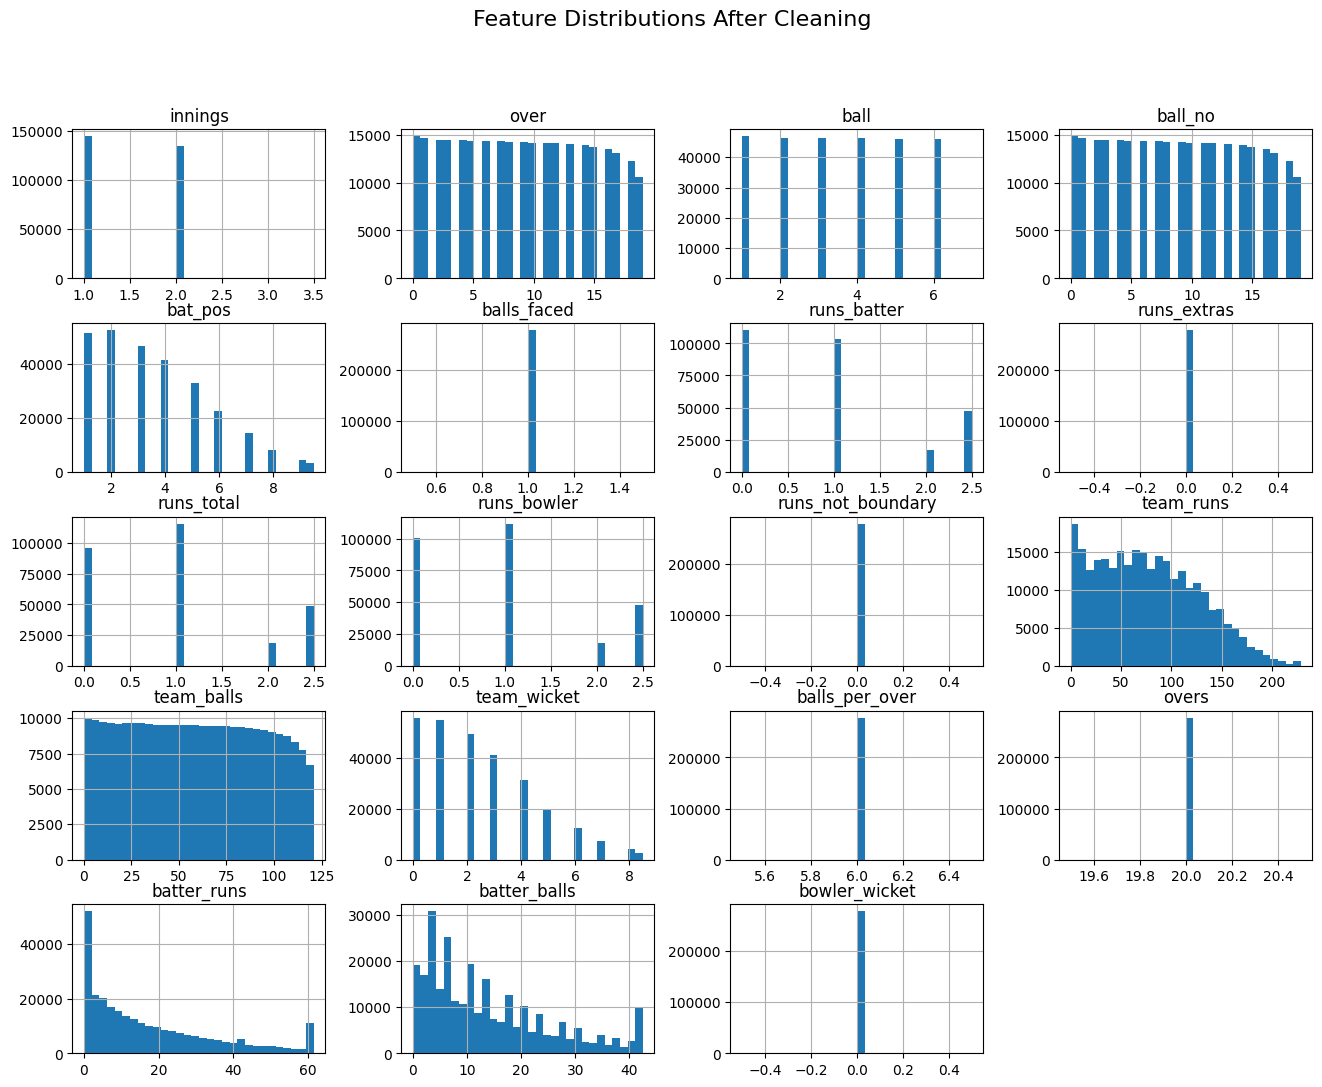


✅ Preprocessing completed
✔ Outliers checked (not re-handled)
✔ Dataset ready for encoding & scaling


In [4]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# STEP 2: LOAD CLEANED DATA
# =========================
df = pd.read_csv(
    "/content/drive/MyDrive/cricket_dataset_cleaned_fixed.csv",
    low_memory=False
)

print("Dataset Shape:", df.shape)

# =========================
# STEP 3: FIX DATA TYPES
# =========================

# Convert date
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Numeric columns
num_cols = [
    'innings', 'over', 'ball', 'ball_no', 'bat_pos',
    'balls_faced', 'runs_batter', 'runs_extras',
    'runs_total', 'runs_bowler', 'runs_not_boundary',
    'team_runs', 'team_balls', 'team_wicket',
    'balls_per_over', 'overs', 'batter_runs',
    'batter_balls', 'bowler_wicket'
]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✔ Data types fixed")

# =========================
# STEP 4: HANDLE MISSING VALUES
# =========================

# Numeric → fill with median
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

# Categorical → fill with 'None'
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna('None', inplace=True)

print("✔ Missing values handled")

# =========================
# STEP 5: OUTLIER CHECKING (NO MODIFICATION)
# =========================

print("\n🔍 Outlier Summary (IQR method):")

outlier_report = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_report[col] = outliers.shape[0]

for k, v in outlier_report.items():
    print(f"{k}: {v} potential outliers")

# =========================
# STEP 6: BOXPLOT VISUAL CHECK
# =========================

plt.figure(figsize=(14, 6))
df[num_cols].boxplot(rot=90)
plt.title("Outlier Check After Cleaning (Verification Only)")
plt.tight_layout()
plt.show()

# =========================
# STEP 7: DISTRIBUTION CHECK
# =========================

df[num_cols].hist(figsize=(16, 12), bins=30)
plt.suptitle("Feature Distributions After Cleaning", fontsize=16)
plt.show()

# =========================
# STEP 8: DATA READY
# =========================

print("\n✅ Preprocessing completed")
print("✔ Outliers checked (not re-handled)")
print("✔ Dataset ready for encoding & scaling")


In [6]:
df.to_csv("/content/drive/MyDrive/cricket_dataset_cleaned_fixed.csv", index=False)
print("✅ Dataset cleaned and saved as 'cricket_dataset_preprocessed.csv'")

✅ Dataset cleaned and saved as 'cricket_dataset_preprocessed.csv'
